<h1>Importing Libraries</h1>

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm

c:\Users\syeda\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\syeda\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


<h1>Creating Directories and loading the datasets </h1>


In [3]:
BASE_DIR = "Data"

TRAIN_NPY_DIR = os.path.join(BASE_DIR, "train")
TEST_NPY_DIR = os.path.join(BASE_DIR, "test")

CSV_PATH = os.path.join(BASE_DIR, "train.csv")

# Output folders
TRAIN_IMG_DIR = "images/train"
VAL_IMG_DIR = "images/val"
TEST_IMG_DIR = "images/test"

LABEL_TRAIN_DIR = "labels/train"
LABEL_VAL_DIR = "labels/val"

os.makedirs(TRAIN_IMG_DIR, exist_ok=True)
os.makedirs(VAL_IMG_DIR, exist_ok=True)
os.makedirs(TEST_IMG_DIR, exist_ok=True)
os.makedirs(LABEL_TRAIN_DIR, exist_ok=True)
os.makedirs(LABEL_VAL_DIR, exist_ok=True)

<h1>Converting the dicom files into images (.jpeg)</h1>

<h3>Below function helps for the Convertion</h3>

In [4]:
def npy_to_jpg(npy_path, output_path):
    
    img = np.load(npy_path)

    # normalize image
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    img = (img * 255).astype(np.uint8)

    # convert grayscale to RGB
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    cv2.imwrite(output_path, img)

<h3>Below Loop Used for the convertion of Training Set</h3>

In [5]:
for file in tqdm(os.listdir(TRAIN_NPY_DIR)):
    
    if file.endswith(".npy"):
        
        npy_path = os.path.join(TRAIN_NPY_DIR, file)
        
        image_id = file.replace(".npy","")
        
        output_path = os.path.join(TRAIN_IMG_DIR, image_id + ".jpg")
        
        npy_to_jpg(npy_path, output_path)

  0%|          | 0/15000 [00:00<?, ?it/s]

100%|██████████| 15000/15000 [03:29<00:00, 71.57it/s]


<h3>Below Loop Used for the Conversion of Testing Set</h3>

In [6]:
for file in tqdm(os.listdir(TEST_NPY_DIR)):
    
    if file.endswith(".npy"):
        
        npy_path = os.path.join(TEST_NPY_DIR, file)
        
        image_id = file.replace(".npy","")
        
        output_path = os.path.join(TEST_IMG_DIR, image_id + ".jpg")
        
        npy_to_jpg(npy_path, output_path)

100%|██████████| 2999/2999 [00:45<00:00, 66.54it/s]


In [7]:
df = pd.read_csv(CSV_PATH)
df.head()

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [8]:
df = df[df["class_id"] != 14]

In [9]:
from sklearn.model_selection import train_test_split

In [11]:
image_ids = df["image_id"].unique().tolist()

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["image_id"].isin(train_ids)]
val_df = df[df["image_id"].isin(val_ids)]

print("Train images:", len(train_ids))
print("Validation images:", len(val_ids))

Train images: 3515
Validation images: 879


In [13]:
df["image_id"].unique().tolist()

['9a5094b2563a1ef3ff50dc5c7ff71345',
 '051132a778e61a86eb147c7c6f564dfe',
 '1c32170b4af4ce1a3030eb8167753b06',
 '0c7a38f293d5f5e4846aa4ca6db4daf1',
 '47ed17dcb2cbeec15182ed335a8b5a9e',
 'd3637a1935a905b3c326af31389cb846',
 'afb6230703512afc370f236e8fe98806',
 '7c1add6833d5f0102b0d3619a1682a64',
 '18a61a07e6f5f13ebfee57fa36cd8b6f',
 '321c111713c3ee5385db0effb54ff568',
 '80caa435b6ab5edaff4a0a758ffaec6e',
 '5da264775732004f1b724b660138854a',
 'fb8e11c6b2886b2d41b379e0598669b9',
 '0622cd29e4e0e4f198abf15614819ae8',
 '347180362348e522905047dde655b6d7',
 '22b8e616a61bbc4caaed0cf23b7159df',
 'c394eadea89e5795c8037280492d116d',
 'be1bb194dfb986bf7554b491852b8901',
 'd7aea6f37597df566725da73655edcc2',
 '8ae85268313b0db2f58d2193aab645c9',
 '8e063eadea9a6aeb684c893c8598be3e',
 '04bb8bd7ee6f88a16623fe5c6dd4da91',
 'bd6eb525438d6da1ced0ed1810857772',
 '4016b176eaf40d514b0559a0aeb48f21',
 '25f2c7b53a6ed09a9aaf73c30357aaf6',
 '18ee9ef3baea468de2087e0edd85e919',
 '7eda1e28e4cee7d8016276c87b76259f',
 

In [14]:
TRAIN_IMG_DIR = "images/train"

LABEL_TRAIN_DIR = "labels/train"
LABEL_VAL_DIR = "labels/val"

os.makedirs(LABEL_TRAIN_DIR, exist_ok=True)
os.makedirs(LABEL_VAL_DIR, exist_ok=True)

<h1>Creating Annotations For YOLO V8</h1>

In [15]:
def create_yolo_labels(df_subset, img_dir, label_dir):

    for image_id in tqdm(df_subset["image_id"].unique()):

        records = df_subset[df_subset["image_id"] == image_id]

        img_path = os.path.join(img_dir, image_id + ".jpg")

        img = cv2.imread(img_path)

        if img is None:
            continue

        h, w, _ = img.shape

        label_path = os.path.join(label_dir, image_id + ".txt")

        with open(label_path, "w") as f:

            for _, row in records.iterrows():

                x_min = row["x_min"]
                y_min = row["y_min"]
                x_max = row["x_max"]
                y_max = row["y_max"]
                class_id = int(row["class_id"])

                x_center = ((x_min + x_max) / 2) / w
                y_center = ((y_min + y_max) / 2) / h
                width = (x_max - x_min) / w
                height = (y_max - y_min) / h

                f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

In [16]:
create_yolo_labels(train_df, TRAIN_IMG_DIR, LABEL_TRAIN_DIR)

100%|██████████| 3515/3515 [00:18<00:00, 194.80it/s]


In [17]:
create_yolo_labels(val_df, TRAIN_IMG_DIR, LABEL_VAL_DIR)

100%|██████████| 879/879 [00:04<00:00, 200.95it/s]


In [1]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

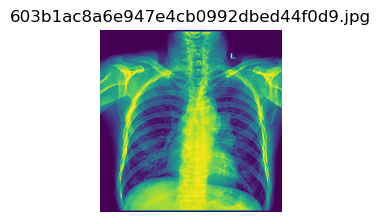

: 

In [ ]:
folder_path = "images/train"

image_files = os.listdir(folder_path)
sample_images = random.sample(image_files, 1)

plt.figure(figsize=(10,5))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(folder_path, img_name)
    img = Image.open(img_path)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)

plt.tight_layout()
plt.show()